In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import statsmodels.formula.api as smf

from scipy.stats import chi2

from utils.configs import REJECT_SID

plt.rc("font", family="Arial")

def convert_pvalue_to_asterisks(pvalue):
    if pvalue <= 0.0001:
        return "****"
    elif pvalue <= 0.001:
        return "***"
    elif pvalue <= 0.01:
        return "**"
    elif pvalue <= 0.05:
        return "*"
    return "n.s."

In [2]:
# Read all behavior results
root = "./data/derivatives/behaviors"

sids = [file.split("_")[0] if file.endswith(".csv") else "None" for file in os.listdir(root)]
sids = list(set(sids))
sids.remove("None")

#####################################################
# Create a new DataFrame object in the below form
#####################################################
# | participant_id | topic_id | sentence_type |   RT   |
# |       1        |     1    |       1       |   rt   |
# |       1        |     1    |       2       |   rt   |
# |       1        |     1    |       3       |   rt   |
# |      ...       |    ...   |      ...      |   rt   |
# |       N        |     T    |       S       |   rt   |
#####################################################

# sentence_type
# 1: 因为外面在下雨，所以地面很潮湿
# 2: 虽然外面在下雨，但是地面很干燥
# 3: 因为外面在下雨，但是地面很干燥
# 4: 虽然外面在下雨，所以地面很潮湿
# 5: 因为外面在下雨，但是地面很潮湿
# 6: 虽然外面在下雨，所以地面很干燥

sentence_type_mapping = [
    [],
    [],
    [1, 3, 4, 2],
    [1, 5, 6, 2]
]

participant_id, topic_id, sentence_type, run, RT = list(), list(), list(), list(), list()
for file in os.listdir(root):
    if not file.endswith(".csv"): continue

    if "run1" in file: continue

    sid = "sub-" + file.split("_")[0].lower()
    if sid in REJECT_SID: continue
    
    df = pd.read_csv(os.path.join(root, file), encoding="utf-8", sep=",")

    stim_fnames = df["Stim_fname"][1:-1].values
    resp_correctness = df["key_resp.corr"][1:-1].values
    resp_times = df["key_resp.rt"][1:-1].values

    for index, (fname, correctness, rt) in enumerate(zip(stim_fnames, resp_correctness, resp_times)):
        topic_id_, block_id_, sent_id_ = fname.replace(".wav", "").split("_")
        block_id_ = int(block_id_.split("-")[-1])
        sent_id_ = int(sent_id_.split("-")[-1])

        if block_id_ == 1: continue
        
        if correctness == 1:
            participant_id.append(sids.index(file.split("_")[0]) + 1)
            topic_id.append(int(topic_id_.split("-")[-1]))
            sentence_type.append(int(sentence_type_mapping[block_id_][sent_id_ - 1]))
            run.append(int(file.split("_")[1].replace("run", "")))
            RT.append(float(rt) * 1000)

df = pd.DataFrame({"participant_id": np.asarray(participant_id, dtype=np.int8), 
                   "topic_id": np.asarray(topic_id, dtype=np.int8), 
                   "sentence_type": np.asarray(sentence_type, dtype=np.int8), 
                   "run": np.asarray(run, dtype=np.int8),
                   "RT": np.asarray(RT, dtype=np.float64)})

df["participant_id"] = df["participant_id"].astype("category")
df["topic_id"] = df["topic_id"].astype("category")
df["run"] = df["run"].astype("category")

# Remove extreme response times: below 200ms or above 3 standard deviations.
rt_mean = df["RT"].mean()
rt_std = df["RT"].std()
cutoff_high = rt_mean + 3 * rt_std
cutoff_low = 200

original_count = len(df)
df = df[(df["RT"] >= cutoff_low) & (df["RT"] <= cutoff_high)]
cleaned_count = len(df)
print(f"Removed {original_count - cleaned_count} trials ({((original_count - cleaned_count)/original_count)*100:.2f}%)")
df["log_RT"] = np.log(df["RT"])

Removed 153 trials (2.80%)


### The 1st Model:
#### RT ~ 1 + Run + ClauseRelation + C1_match + C2_match + (1 | Participant) + (1 | Topic)

In [3]:
# Perform Linear Mixed Effective Model
# RT ~ 1 + Run + ClauseRelation + C1_match + C2_match + (1 | Participant) + (1 | Topic)

df_m = df.copy()
df_m["C1"] = np.where(df["sentence_type"].isin([1, 3, 5]), "因为", "虽然")
df_m["C2"] = np.where(df["sentence_type"].isin([1, 4, 6]), "所以", "但是")
df_m["ClauseRelation"] = np.where(df_m["sentence_type"].isin([1, 4, 5]), 1, -1)

df_m["C1_match"] = -1
df_m.loc[((df_m["ClauseRelation"] == 1) & (df_m["C1"] == "因为")) | 
         ((df_m["ClauseRelation"] == -1) & (df_m["C1"] == "虽然")), "C1_match"] = 1

df_m["C2_match"] = -1
df_m.loc[((df_m["ClauseRelation"] == 1) & (df_m["C2"] == "所以")) | 
         ((df_m["ClauseRelation"] == -1) & (df_m["C2"] == "但是")), "C2_match"] = 1

df_m.drop(labels=["sentence_type"], axis=1)

formula = "RT ~ C(run) + ClauseRelation + C1_match + C2_match"
model1 = smf.mixedlm(
    formula, 
    df_m, 
    groups=df_m["participant_id"],
    vc_formula={"topic_id": "0 + C(topic_id)"}
).fit(reml=False)

print(model1.summary())

# Results explanation
print("\n=== Results explanation ===")
print(f"Coef of C1_match: {model1.params["C1_match"]:.4f}")
print(f"Coef of C2_match: {model1.params["C2_match"]:.4f}")

c1_effect = abs(model1.params["C1_match"])
c2_effect = abs(model1.params["C2_match"])

if c1_effect > c2_effect:
    print(f"Greater effect of C1_match: ({c1_effect:.4f} vs {c2_effect:.4f})")
else:
    print(f"Greater effect of C2_match: ({c2_effect:.4f} vs {c1_effect:.4f})")

c1_pvalue = model1.pvalues["C1_match"]
c2_pvalue = model1.pvalues["C2_match"]

print(f"P-value of C1_match: {c1_pvalue:.4f}")
print(f"P-value of C2_match: {c2_pvalue:.4f}")

if c1_pvalue < 0.05 and c2_pvalue < 0.05:
    print("Both effects are significant.")
elif c1_pvalue < 0.05:
    print("Only the C1_match effect is significant")
elif c2_pvalue < 0.05:
    print("Only the C2_match effect is significant")
else:
    print("Both effects are not significant.")

# Compare models to test the importance of C1_match and C2_match
print("\n=== Model Comparations ===")

# Without C1_match
model1_no_c1 = smf.mixedlm(
    "RT ~ C(run) + ClauseRelation + C2_match",
    df_m, 
    groups=df["participant_id"],
    vc_formula={"topic_id": "0 + C(topic_id)"}
).fit(reml=False)

# Without C2_match
model1_no_c2 = smf.mixedlm(
    "RT ~ C(run) + ClauseRelation + C1_match",
    df_m, 
    groups=df["participant_id"],
    vc_formula={"topic_id": "0 + C(topic_id)"}
).fit(reml=False)

# Model comparations
print("Full model vs Model without C1_match:")
lr_test_c1 = 2 * (model1.llf - model1_no_c1.llf)
p_value_c1 = 1 - chi2.cdf(lr_test_c1, 1)
print(f"Likelihood ratio test statistic: {lr_test_c1:.4f}, p_value: {p_value_c1:.4f}")

print("Full model vs Model without C2_match:")
lr_test_c2 = 2 * (model1.llf - model1_no_c2.llf)
p_value_c2 = 1 - chi2.cdf(lr_test_c2, 1)
print(f"Likelihood ratio test statistic: {lr_test_c2:.4f}, p_value: {p_value_c2:.4f}")

            Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  RT         
No. Observations:    5308     Method:              ML         
No. Groups:          34       Scale:               53781.6793 
Min. group size:     118      Log-Likelihood:      -36681.9750
Max. group size:     167      Converged:           Yes        
Mean group size:     156.1                                    
--------------------------------------------------------------
                 Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
--------------------------------------------------------------
Intercept        663.184   10.361 64.005 0.000 642.876 683.492
C(run)[T.3]      -19.260    7.804 -2.468 0.014 -34.555  -3.965
C(run)[T.4]      -12.786    7.798 -1.640 0.101 -28.068   2.497
ClauseRelation    -2.600    3.188 -0.816 0.415  -8.848   3.648
C1_match           2.278    3.925  0.580 0.562  -5.414   9.970
C2_match          12.026    3.881  3.098 0.002   4.419  19.633
topic

### Visualize the 1st Model

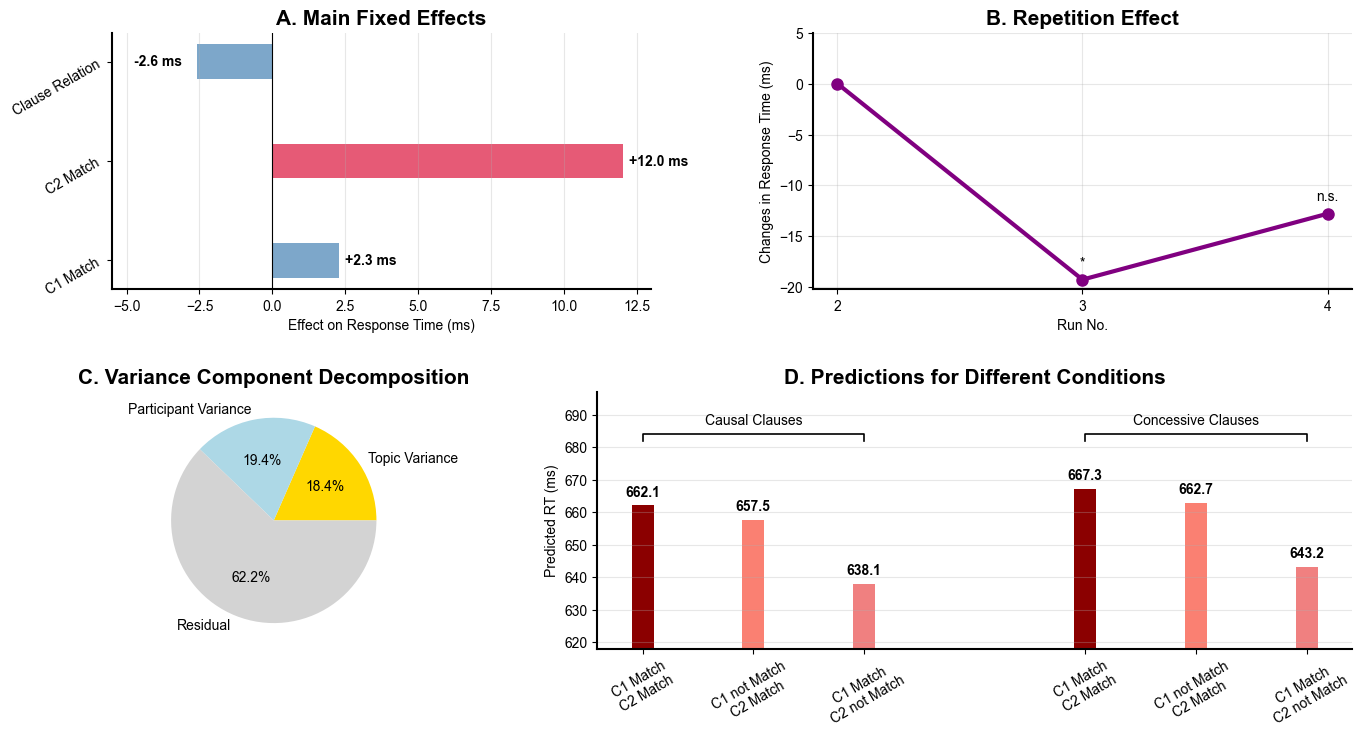

In [4]:
fig = plt.figure(figsize=(16, 8))

gs_main = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[1, 1], hspace=0.4)
gs_upper = gridspec.GridSpecFromSubplotSpec(
    1, 2, 
    subplot_spec=gs_main[0], 
    width_ratios=[1, 1], 
    wspace=0.3
)
gs_lower = gridspec.GridSpecFromSubplotSpec(
    1, 2, 
    subplot_spec=gs_main[1], 
    width_ratios=[0.3, 0.7], 
    wspace=0.3
)

p_thres = 0.05

# 1. Main effect
ax1 = fig.add_subplot(gs_upper[0])
variables = ["C1 Match", "C2 Match", "Clause Relation"]
effects = [model1.params["C1_match"], model1.params["C2_match"], model1.params["ClauseRelation"]]
colors = ["crimson" if model1.pvalues["C1_match"] < p_thres else "steelblue",
          "crimson" if model1.pvalues["C2_match"] < p_thres else "steelblue",
          "crimson" if model1.pvalues["ClauseRelation"] < p_thres else "steelblue"]

bars = ax1.barh(variables, effects, height=0.35, color=colors, alpha=0.7)
ax1.axvline(x=0, color="black", linewidth=0.8)
ax1.set_xlim(left=-5.5, right=13)
ax1.set_xlabel("Effect on Response Time (ms)")
ax1.set_title("A. Main Fixed Effects", fontweight="bold", fontsize=15)
ax1.grid(True, axis="x", alpha=0.3)
ax1.spines["right"].set_visible(False)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_linewidth(1.5)
ax1.spines["left"].set_linewidth(1.5)
ax1.set_yticks([0, 1, 2])
ax1.set_yticklabels(variables, rotation=30)

for i, (effect, bar) in enumerate(zip(effects, bars.patches)):
    x_pos = effect + (0.2 if effect > 0 else -0.5)
    ax1.text(x_pos, bar.get_y() + bar.get_height()/2, 
             f"{effect:+.1f} ms", ha="left" if effect > 0 else "right", 
             va="center", fontweight="bold")

# 2. Repetition effect
ax2 = fig.add_subplot(gs_upper[1])
runs = [2, 3, 4]
run_effects = [0, model1.params["C(run)[T.3]"], model1.params["C(run)[T.4]"]]

ax2.plot(runs, run_effects, "o-", linewidth=3, markersize=8, color="purple")
ax2.text(runs[1], model1.params["C(run)[T.3]"] + 1, convert_pvalue_to_asterisks(model1.pvalues["C(run)[T.3]"]), 
         ha="center", va="bottom", color="k", fontsize=10)
ax2.text(runs[2], model1.params["C(run)[T.4]"] + 1, convert_pvalue_to_asterisks(model1.pvalues["C(run)[T.4]"]), 
         ha="center", va="bottom", color="k", fontsize=10)
ax2.set_xlabel("Run No.")
ax2.set_ylabel("Changes in Response Time (ms)")
ax2.set_title("B. Repetition Effect", fontweight="bold", fontsize=15)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(runs)
ax2.set_ylim(top=int(max(run_effects) + 5))
ax2.spines["right"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax2.spines["bottom"].set_linewidth(1.5)
ax2.spines["left"].set_linewidth(1.5)

# 3. Variance Component
ax3 = fig.add_subplot(gs_lower[0])
model1_simple = smf.mixedlm(
    "RT ~ C(run) + ClauseRelation + C1_match + C2_match",
    df_m, 
    groups=df_m["participant_id"]
).fit()

variance_sources = ["Topic Variance", "Participant Variance", "Residual"]
variance_values = [model1.vcomp[0], model1_simple.cov_re.iloc[0,0], model1.scale]

wedges, texts, autotexts = ax3.pie([v/max(variance_values)*100 for v in variance_values], 
                                   labels=variance_sources, autopct='%1.1f%%',
                                   colors=["gold", "lightblue", "lightgray"],
                                   textprops={"fontsize": 10, "fontweight": "normal"})
ax3.set_title("C. Variance Component Decomposition", fontweight="bold", fontsize=15)

# 4. Predictions for Conditional Combinations
ax4 = fig.add_subplot(gs_lower[1])
conditions = ["C1 Match\nC2 Match", "C1 not Match\nC2 Match", "C1 Match\nC2 not Match"]

positions_cc = [1, 2, 3]
positions_ic = [5, 6, 7]

df_conditions = pd.DataFrame({
    "run": [4, 4, 4],
    "ClauseRelation": [1, 1, 1], # Consistent clauses
    "C1_match": [1, -1, 1],
    "C2_match": [1, 1, -1],
    "topic_id": [1, 1, 1]  # Any topic iD at will
})
predicted_rt_cc = model1.predict(df_conditions)
bars = ax4.bar(positions_cc, predicted_rt_cc, width=0.2,
               color=["darkred", "salmon", "lightcoral"])

df_conditions = pd.DataFrame({
    "run": [4, 4, 4],
    "ClauseRelation": [-1, -1, -1], # Inconsistent clauses
    "C1_match": [1, -1, 1],
    "C2_match": [1, 1, -1],
    "topic_id": [1, 1, 1]
})
predicted_rt_ic = model1.predict(df_conditions)
bars = ax4.bar(positions_ic, predicted_rt_ic, width=0.2,
               color=["darkred", "salmon", "lightcoral"])

top = np.max(np.concatenate([predicted_rt_cc, predicted_rt_ic]))
bottom = np.min(np.concatenate([predicted_rt_cc, predicted_rt_ic]))

x1, x2 = positions_cc[0], positions_cc[-1]
y, h = int(top + 15), 2
ax4.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c="k")
ax4.text((x1 + x2) * 0.5, y + h * 2, "Causal Clauses", ha="center", va="bottom", color="k", fontsize=10)
for i in range(3):
    ax4.text(positions_cc[i], predicted_rt_cc[i] + h, f"{predicted_rt_cc[i]:.1f}", 
             ha="center", va="bottom", color="k", fontsize=10, fontweight="bold")

x1, x2 = positions_ic[0], positions_ic[-1]
y, h = int(top + 15), 2
ax4.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c="k")
ax4.text((x1 + x2) * 0.5, y + h * 2, "Concessive Clauses", ha="center", va="bottom", color="k", fontsize=10)
for i in range(3):
    ax4.text(positions_ic[i], predicted_rt_ic[i] + h, f"{predicted_rt_ic[i]:.1f}", 
             ha="center", va="bottom", color="k", fontsize=10, fontweight="bold")

ax4.set_xticks(positions_cc + positions_ic)
ax4.set_xticklabels(conditions * 2, rotation = 30)
ax4.set_ylabel("Predicted RT (ms)")
ax4.set_title("D. Predictions for Different Conditions", fontweight="bold", fontsize=15)
ax4.spines["right"].set_visible(False)
ax4.spines["top"].set_visible(False)
ax4.spines["bottom"].set_linewidth(1.5)
ax4.spines["left"].set_linewidth(1.5)
ax4.grid(True, axis="y", alpha=0.3)
ax4.tick_params(axis="x", rotation=30)
ax4.set_ylim(top=int(top + 30) ,bottom=int(bottom - 20))

plt.show()

### The 2nd Model:
#### RT ~ 1 + Run + ClauseRelation + Condition + (1 | Participant) + (1 | Topic)

In [ ]:
# RT ~ 1 + Run + ClauseRelation + Condition + (1 | Participant) + (1 | Topic)
# Create a new category column "Condition"
conditions = []
for index, row in df_m.iterrows():
    if row["C1_match"] == 1 and row["C2_match"] == 1:
        conditions.append("Standard")
    elif row["C1_match"] == -1 and row["C2_match"] == 1:
        conditions.append("C2_Match_Only")  # Block 2 Dev
    elif row["C1_match"] == 1 and row["C2_match"] == -1:
        conditions.append("C1_Match_Only") # Block 3 Dev
    else:
        conditions.append("Double_Mismatch") # This item should not exist.

df_m["Condition"] = conditions

# Set "Standard" as the baseline (Reference Level).
formula = "RT ~ C(run) + ClauseRelation + C(Condition, Treatment(reference='Standard'))"

model2 = smf.mixedlm(
    formula, 
    df_m, 
    groups=df_m["participant_id"],
    vc_formula={"topic_id": "0 + C(topic_id)"}
).fit()

print(model2.summary())

# Save results
save_dir = "./results/2.2-Behavior_Effect_Analysis"
os.makedirs(save_dir, exist_ok=True)

with open(os.path.join(save_dir, "rt_model_summary.txt"), "w", encoding="utf-8") as f:
    f.write(model2.summary().as_text())

fe = pd.DataFrame({
    "term": model2.fe_params.index,
    "estimate": model2.fe_params.values,
    "se": model2.bse_fe.reindex(model2.fe_params.index).values,
    "zvalue": (model2.fe_params / model2.bse_fe.reindex(model2.fe_params.index)).values,
    "pvalue":model2.pvalues.reindex(model2.fe_params.index).values,
})
fe.to_csv(os.path.join(save_dir, "rt_model_fixed_effects.csv"), index=False)

# model2.k_fe : number of fixed effects
# model2.model.exog_names : List of names of fixed effects
num_fixed_effects = model2.k_fe
fe_names = model2.model.exog_names

print(f"固定效应数量: {num_fixed_effects}")
print(f"固定效应名称: {fe_names}")

contrast_matrix = np.zeros((1, num_fixed_effects))

term_c1 = "C(Condition, Treatment(reference='Standard'))[T.C1_Match_Only]"
term_c2 = "C(Condition, Treatment(reference='Standard'))[T.C2_Match_Only]"

try:
    idx_c1 = fe_names.index(term_c1)
    idx_c2 = fe_names.index(term_c2)
except ValueError as e:
    print("\n【错误】: 找不到指定的变量名。请检查 print 输出的名称是否与代码中的字符串一致。")
    raise e

# H0: Global = Local  =>  Global - Local = 0
contrast_matrix[0, idx_c1] = 1
contrast_matrix[0, idx_c2] = -1

t_test_result = model2.t_test(contrast_matrix)

print("\n=== Contrast Result: Global vs Local ===")
print(t_test_result)

                                    Mixed Linear Model Regression Results
Model:                               MixedLM                  Dependent Variable:                  RT         
No. Observations:                    5308                     Method:                              REML       
No. Groups:                          34                       Scale:                               53834.5771 
Min. group size:                     118                      Log-Likelihood:                      -36665.1101
Max. group size:                     167                      Converged:                           Yes        
Mean group size:                     156.1                                                                    
--------------------------------------------------------------------------------------------------------------
                                                                 Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
--------------------------------------

### Visualize the 2nd Model

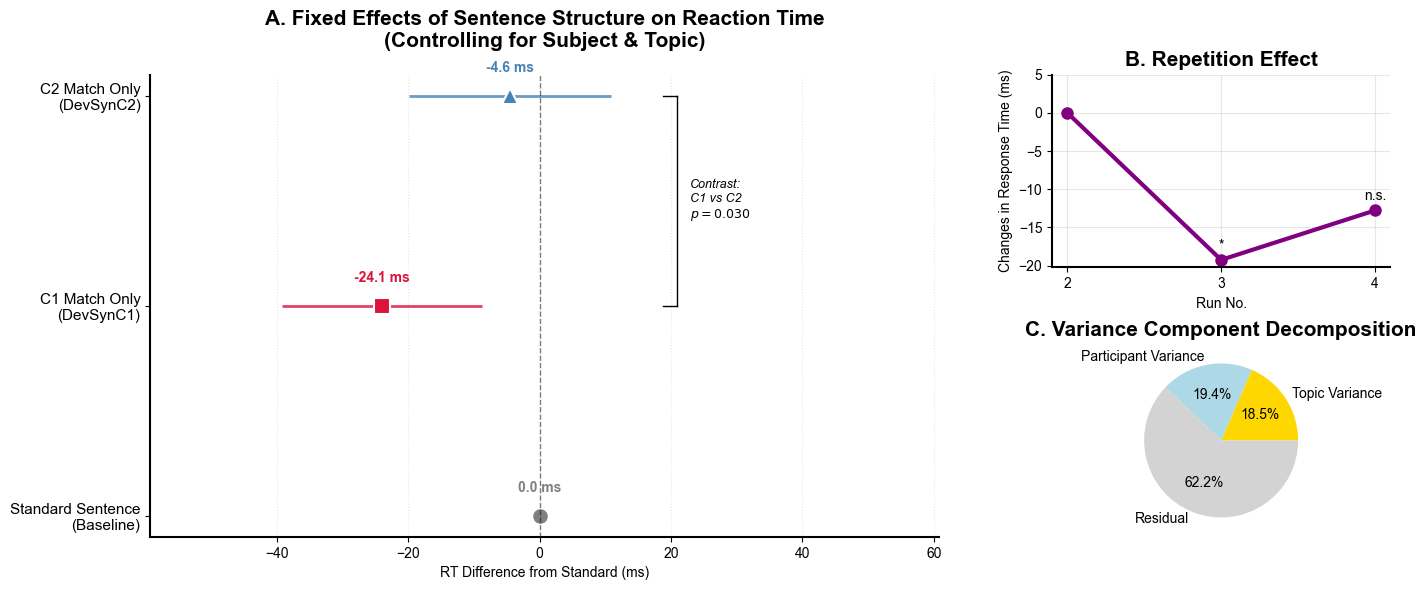

In [6]:
fig = plt.figure(figsize=(16, 6))

gs_main = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[0.7, 0.3], wspace=0.2)

gs_left = gs_main[0]
gs_right = gridspec.GridSpecFromSubplotSpec(
    2, 1, 
    subplot_spec=gs_main[1], 
    height_ratios=[1, 1],
    hspace=0.4
)

p_thres = 0.05

# 1. Fixed effect
ax1 = fig.add_subplot(gs_left)

conf = model2.conf_int()
conf.columns = ["CI_Lower", "CI_Upper"]

results_df = pd.concat([model2.params, conf], axis=1)
results_df.columns = ["Coef", "CI_Lower", "CI_Upper"]

target_vars = [
    "C(Condition, Treatment(reference='Standard'))[T.C1_Match_Only]",
    "C(Condition, Treatment(reference='Standard'))[T.C2_Match_Only]"
]

rename_map = {
    "C(Condition, Treatment(reference='Standard'))[T.C1_Match_Only]": "C1 Match Only\n(DevSynC1)",
    "C(Condition, Treatment(reference='Standard'))[T.C2_Match_Only]": "C2 Match Only\n(DevSynC2)"
}

plot_df = results_df.loc[target_vars].copy()
plot_df = plot_df.rename(index=rename_map)

standard_row = pd.DataFrame({"Coef": [0], "CI_Lower": [0], "CI_Upper": [0]}, index=["Standard Sentence\n(Baseline)"])
plot_df = pd.concat([standard_row, plot_df])

colors = ["gray", 
          "crimson" if model2.pvalues["C(Condition, Treatment(reference='Standard'))[T.C1_Match_Only]"] < p_thres else "steelblue", 
          "crimson" if model2.pvalues["C(Condition, Treatment(reference='Standard'))[T.C2_Match_Only]"] < p_thres else "steelblue"] 
markers = ["o", "s", "^"]

y_pos = np.arange(len(plot_df))

for i, (idx, row) in enumerate(plot_df.iterrows()):
    ax1.hlines(y=i, xmin=row["CI_Lower"], xmax=row["CI_Upper"], color=colors[i], linewidth=2, alpha=0.8)
    ax1.plot(row["Coef"], i, marker=markers[i], markersize=12, color=colors[i], label=idx, markeredgecolor="white", markeredgewidth=1.5)
    ax1.text(row["Coef"], i + 0.1, f"{row["Coef"]:.1f} ms", ha="center", va="bottom", fontsize=10, fontweight="bold", color=colors[i])

ax1.axvline(x=0, color="black", linestyle="--", linewidth=1, alpha=0.5)

y_min, y_max = 1, 2
x_pos = max(plot_df.iloc[1]["CI_Upper"], plot_df.iloc[2]["CI_Upper"]) + 10

ax1.plot([x_pos, x_pos], [y_min, y_max], color="black", linewidth=1)
ax1.plot([x_pos, x_pos-2], [y_min, y_min], color="black", linewidth=1)
ax1.plot([x_pos, x_pos-2], [y_max, y_max], color="black", linewidth=1)

ax1.text(x_pos + 2, (y_min + y_max)/2, f"Contrast:\nC1 vs C2\n$p = {t_test_result.pvalue:.3f}$", 
         ha="left", va="center", fontsize=9, fontstyle="italic")

ax1.set_yticks(y_pos, plot_df.index, fontsize=11)
ax1.set_xlabel("RT Difference from Standard (ms)")
ax1.set_title("A. Fixed Effects of Sentence Structure on Reaction Time\n(Controlling for Subject & Topic)", fontweight="bold", fontsize=15, pad=20)
ax1.set_xlim(min(plot_df["CI_Lower"]) - 20, max(plot_df["CI_Upper"]) + 50)
ax1.grid(axis="x", linestyle=":", alpha=0.3)
ax1.spines["right"].set_visible(False)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_linewidth(1.5)
ax1.spines["left"].set_linewidth(1.5)

# 2. Repetition effect
ax2 = fig.add_subplot(gs_right[0])
runs = [2, 3, 4]
run_effects = [0, model2.params["C(run)[T.3]"], model2.params["C(run)[T.4]"]]

ax2.plot(runs, run_effects, "o-", linewidth=3, markersize=8, color="purple")
ax2.text(runs[1], model2.params["C(run)[T.3]"] + 1, convert_pvalue_to_asterisks(model2.pvalues["C(run)[T.3]"]), 
         ha="center", va="bottom", color="k", fontsize=10)
ax2.text(runs[2], model2.params["C(run)[T.4]"] + 1, convert_pvalue_to_asterisks(model2.pvalues["C(run)[T.4]"]), 
         ha="center", va="bottom", color="k", fontsize=10)
ax2.set_xlabel("Run No.")
ax2.set_ylabel("Changes in Response Time (ms)")
ax2.set_title("B. Repetition Effect", fontweight="bold", fontsize=15)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(runs)
ax2.set_ylim(top=int(max(run_effects) + 5))
ax2.spines["right"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax2.spines["bottom"].set_linewidth(1.5)
ax2.spines["left"].set_linewidth(1.5)

# 3. Variance Component
ax3 = fig.add_subplot(gs_right[1])
model1_simple = smf.mixedlm(
    "RT ~ C(run) + ClauseRelation + C1_match + C2_match",
    df_m, 
    groups=df_m["participant_id"]
).fit()

variance_sources = ["Topic Variance", "Participant Variance", "Residual"]
variance_values = [model2.vcomp[0], model1_simple.cov_re.iloc[0,0], model2.scale]

wedges, texts, autotexts = ax3.pie([v/max(variance_values)*100 for v in variance_values], 
                                   labels=variance_sources, autopct='%1.1f%%',
                                   colors=["gold", "lightblue", "lightgray"],
                                   textprops={"fontsize": 10, "fontweight": "normal"})
ax3.set_title("C. Variance Component Decomposition", fontweight="bold", fontsize=15)

plt.show()